## Boston datase

A real estate company wants to predict house prices so they can make better decisions.

Why needed?

Set correct house price 
Help buyers and sellers
Avoid overpricing / underpricing

Type of problem:  Regression Problem     Model = Multiple Linear Regression

Because:          Output (medv) is a number (price)
                  Not category (like yes/no)

I want to predict house prices
I am building a regression model to predict house prices based on different features like number of rooms, crime rate, etc.
I am using: Public dataset (Boston Housing)

#### COLUMN   ------------------              MEANING

###### Unnamed------------------------------------------- Just a serial number not need for model, we'll remove it.
###### crim  ----     Crime rate ------------------------ How much crime rate in that area,high crime- low house price, low crime- high house price
###### zn	----         Residential land(%) ----------- Big residential area , Higher- rich area, lower- normal area
###### indus	----     Industrial area ------------------- Factories, more industry-less price, less industry-better living
###### chas	----     Near river (0/1) ------------------ Near river(1) or not(0)- near river - price may increase
###### nox	----         Pollution level --------------- high pollution- low price, low pollution-high price.
###### rm	----         Rooms in house  --------------- more rooms- high price
###### age	----         Old houses (%)  --------------- high-older area, low-newer area
###### dis	----         Distance to jobs -------------- Far → less convenient, Near → better
###### rad	----         Road access   ----------------- Higher → better transport
###### tax	----        Property tax   ----------------- High tax → expensive area
###### ptratio	----     Student-teacher ratio  -------- student per teacher , High ratio → poor education ,Low ratio → better schools
###### black	 ----    Population factor ----------------- Population-related metric (technical)
###### lstat	 ----    Low income (%) -------------------- High → lower house price, Low → higher price
###### medv	 ----    House price  ---------------------- this is what we predicted (House Price-output)

In [41]:
# we can collect data ,after using this method
'''import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
data = pd.read_csv(url)'''

In [7]:
#importing library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
df = pd.read_csv('Boston.csv')


In [9]:
df

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### Basic Checks

In [10]:
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [11]:
df.tail()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,506,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [12]:
df.columns

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


In [14]:
df.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [15]:
df.shape

(506, 15)

In [16]:
df.isnull().sum()

Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64

In [17]:
df

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### EDA (Exploratory Data Analysis)

In [18]:
#Basic statistics- mean, min / max, std
#Helps understand: Data range , Distributio
df.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


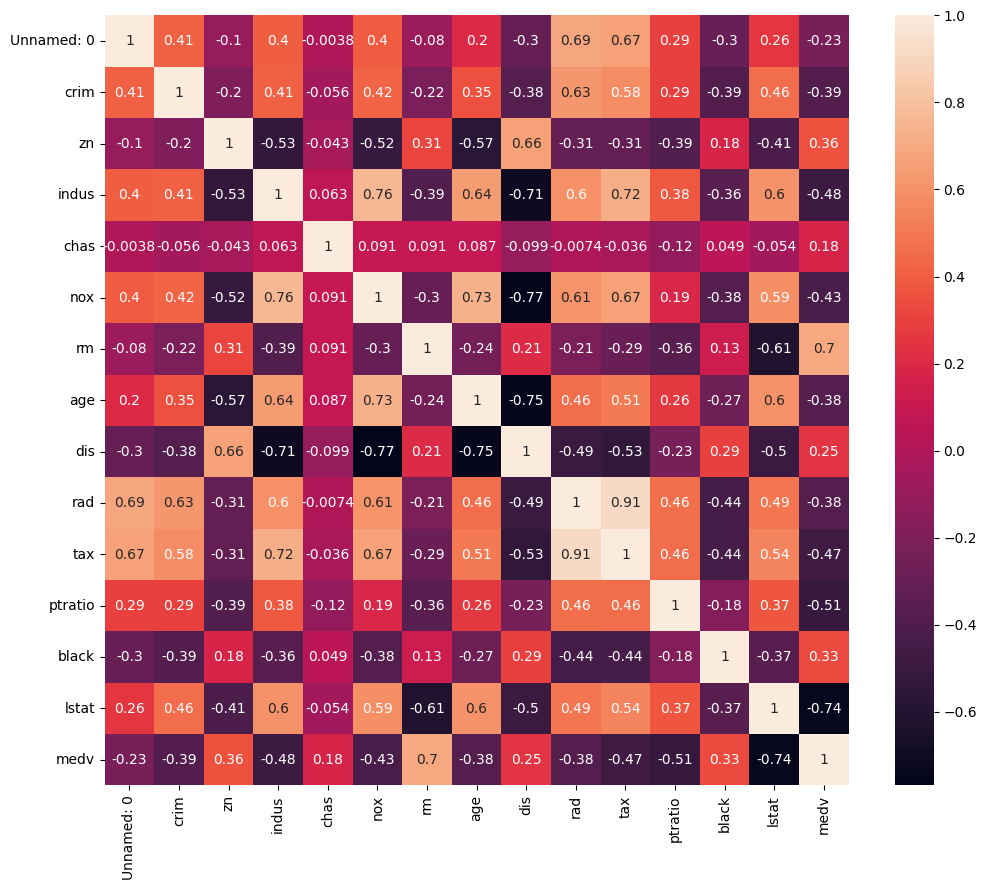

In [19]:
#correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

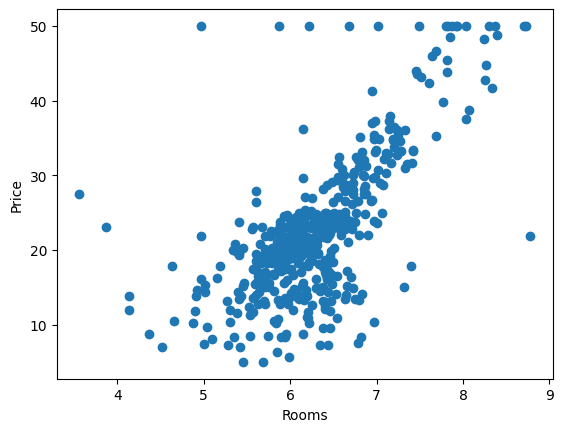

In [24]:
#Scatter plot - relationship check ---- Rooms vs Price

plt.scatter(df['rm'], df['medv'])
plt.xlabel("Rooms")
plt.ylabel("Price")
plt.show()

#more room higher price


In [ ]:
sns.relplot(x='rm',y='medv',data=data)


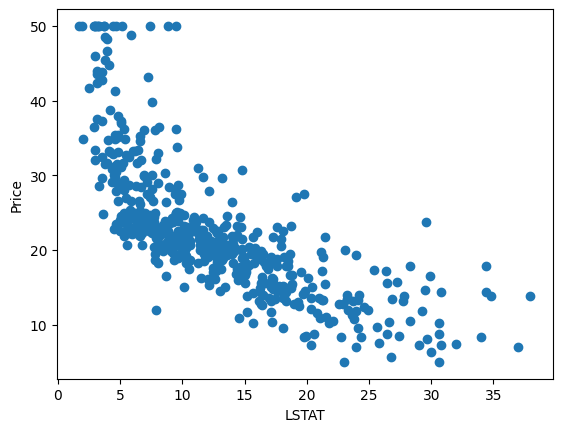

In [26]:
#LSTAT vs Price

plt.scatter(df['lstat'], df['medv'])
plt.xlabel("LSTAT")
plt.ylabel("Price")
plt.show()

#more poverty lower price

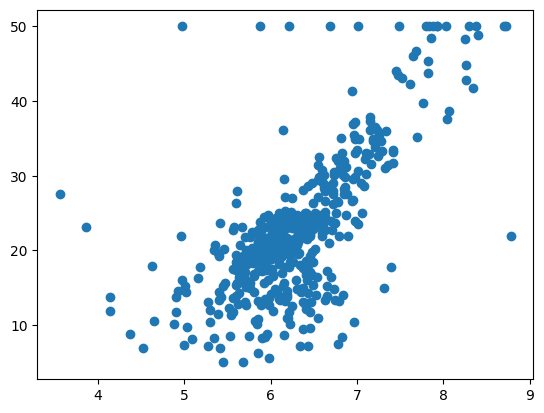

In [28]:
plt.scatter(x='rm',y='medv',data=df)


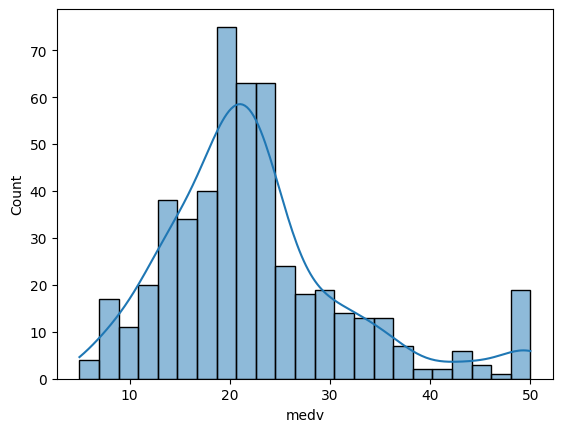

In [30]:
#distribution plots
sns.histplot(df['medv'], kde=True)
plt.show()

#check data is normal or skewed

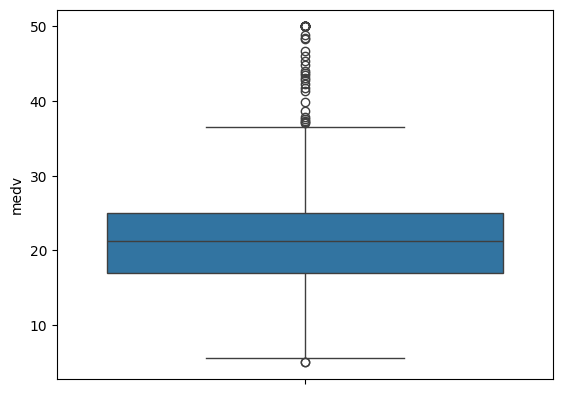

In [31]:
#Outlier detection
sns.boxplot(df['medv'])
plt.show()

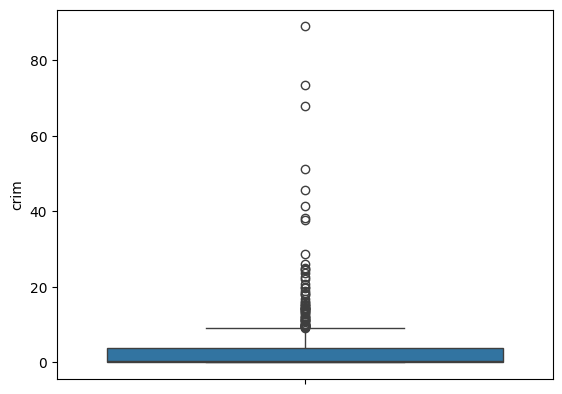

In [32]:
sns.boxplot(df['crim'])
plt.show()

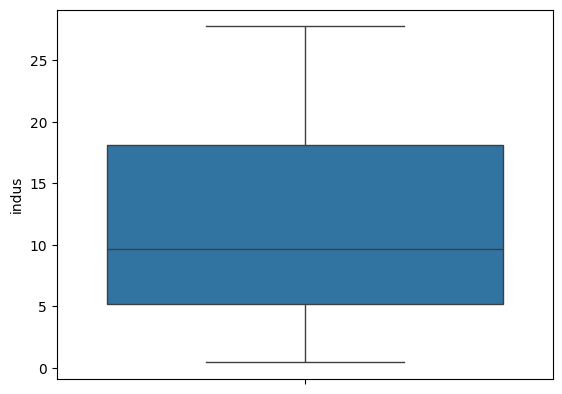

In [33]:
sns.boxplot(df['indus'])
plt.show()

In [34]:

df.corr()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,-0.295041,0.258465,-0.226604
crim,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626


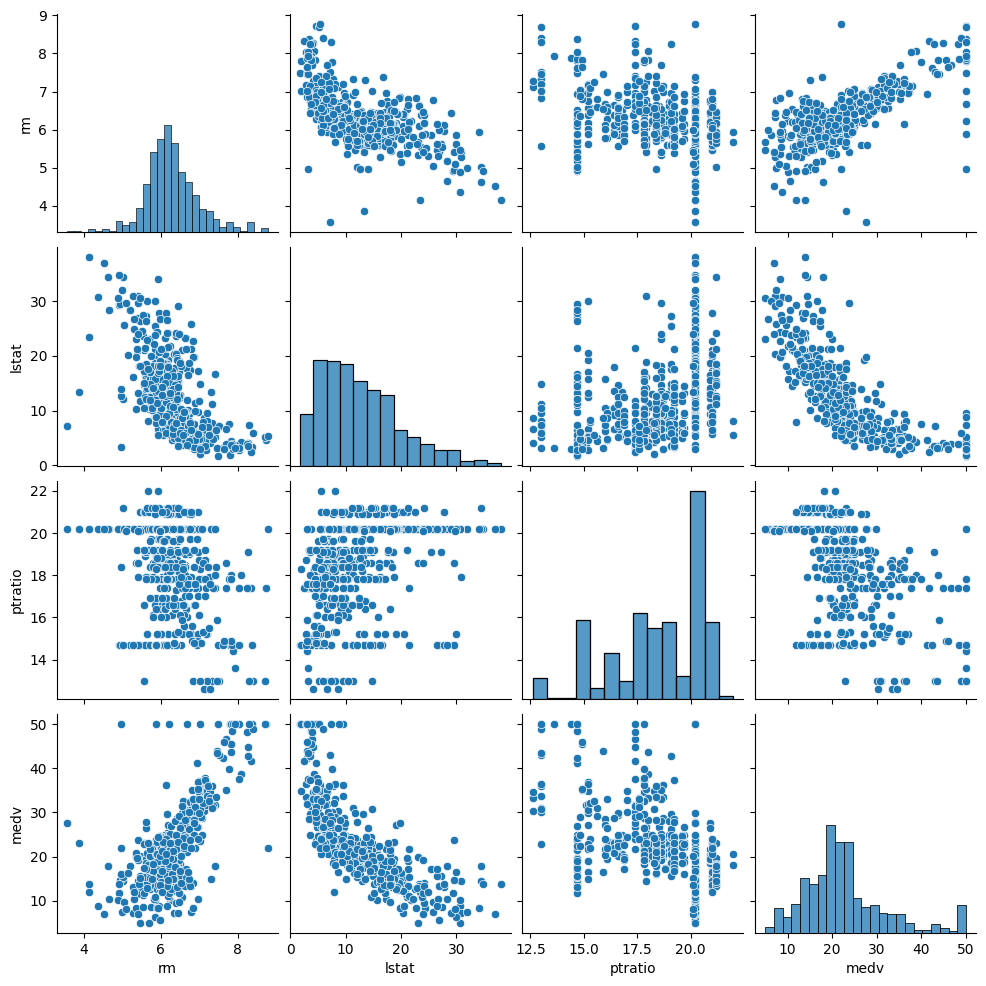

In [35]:
#multivariet analysis

cols = ['rm', 'lstat', 'ptratio', 'medv']
sns.pairplot(df[cols])

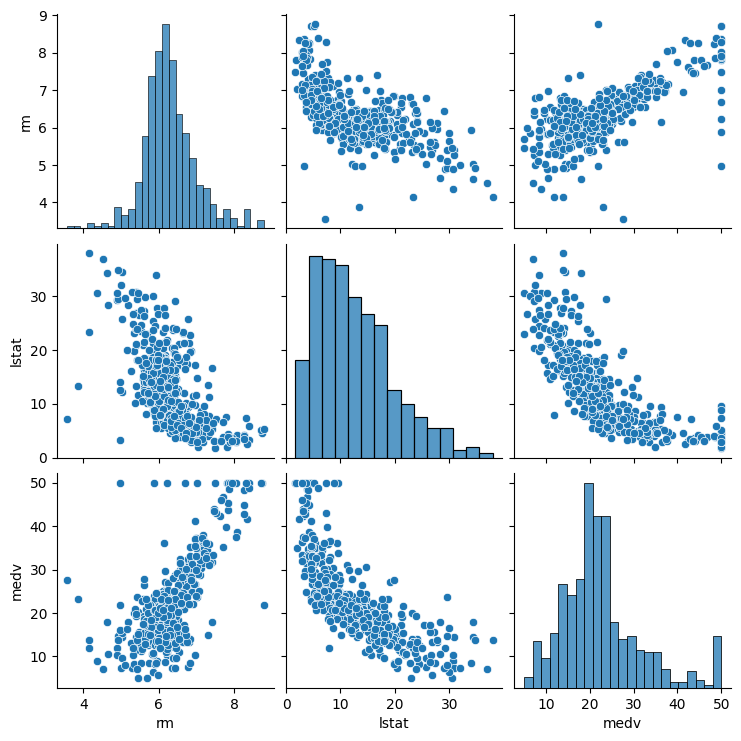

In [37]:
sns.pairplot(df[['rm', 'lstat', 'medv']])

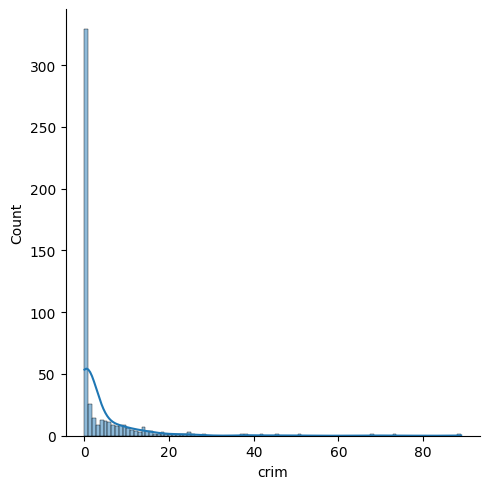

In [38]:
#univariate analaysis
sns.displot(x=df.crim,kde=True)

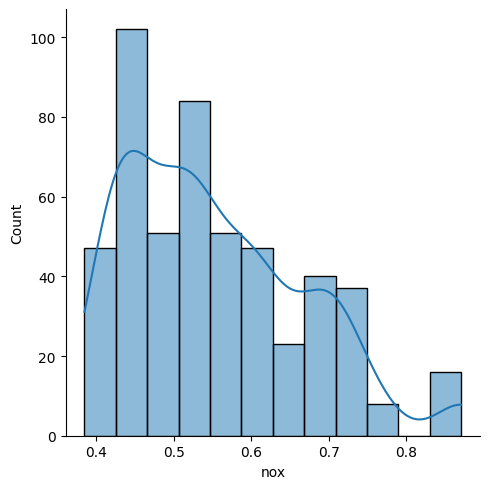

In [39]:
sns.displot(x=df.nox,kde=True)

In [ ]:
#Bivarient analysis:- Study relationship between 2 variables


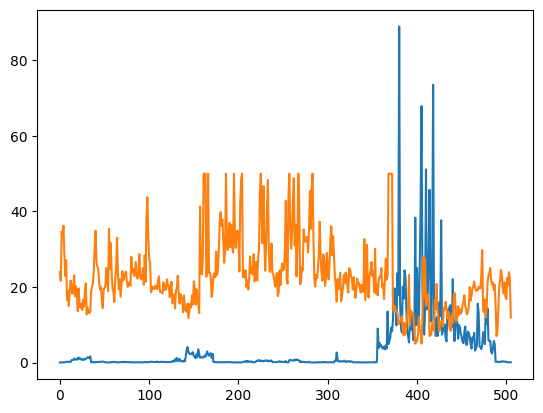

In [40]:
plt.plot(df.crim)
plt.plot(df.medv)

### Data Preprocessing 
Cleaning and preparing data before giving it to the model

In [41]:
# Remove unnecessary column 
# In my dataset Boston 1 column is unnamed so remove it.
df = df.drop('Unnamed: 0', axis=1)

In [42]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [43]:
# check missing value
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

In [ ]:
# if missing value is available then use this line of code
#df=df.fillna(df.mean())

In [44]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#if duplicate value is available then use this line of code
#df=df.drop_duplicates()

In [ ]:
#feature selection
#l1=['Unnamed: 0']
#data.drop(l1,axis=1,inplace=True)

<Axes: >

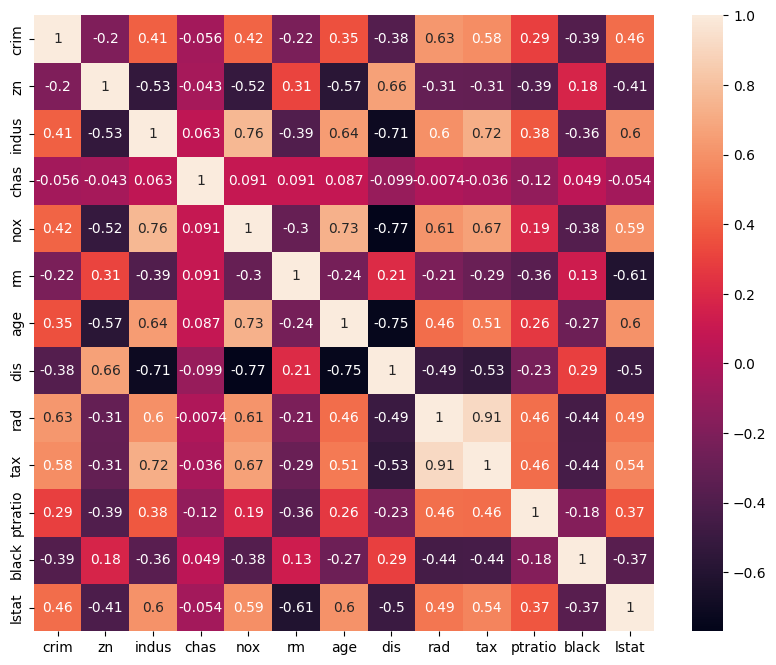

In [46]:
#cheaking the correlation
plt.figure(figsize=(10,8))

sns.heatmap(df.drop('medv', axis=1).corr(), annot=True)


In [47]:
df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


### Model Creation :-
Teaching the machine to learn from data and make predictions

In [48]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [49]:
#step1:- Independent and Dependent variable creation
X=[['crim','zn','chas','nox','rm','age','dis','rad','tax','ptratio','black','lstat']]
y=df.medv

In [50]:
X

[['crim',
  'zn',
  'chas',
  'nox',
  'rm',
  'age',
  'dis',
  'rad',
  'tax',
  'ptratio',
  'black',
  'lstat']]

In [51]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64

In [52]:
import sklearn

In [95]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [58]:
# Step 1: define X and y
X = df[['crim','zn','chas','nox','rm','age','dis','rad','tax','ptratio','black','lstat']]
y = df['medv']

# Step 2: check shape
print(X.shape)
print(y.shape)

# Step 3: split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

(506, 12)
(506,)


In [59]:
X_train

,crim,zn,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
192,0.08664,45.0,0,0.437,7.178,26.3,6.4798,5,398,15.2,390.49,2.87
138,0.24980,0.0,0,0.624,5.857,98.2,1.6686,4,437,21.2,392.04,21.32
251,0.21409,22.0,0,0.431,6.438,8.9,7.3967,7,330,19.1,377.07,3.59
13,0.62976,0.0,0,0.538,5.949,61.8,4.7075,4,307,21.0,396.90,8.26
256,0.01538,90.0,0,0.394,7.454,34.2,6.3361,3,244,15.9,386.34,3.11
...,...,...,...,...,...,...,...,...,...,...,...,...
385,16.81180,0.0,0,0.700,5.277,98.1,1.4261,24,666,20.2,396.90,30.81
197,0.04666,80.0,0,0.404,7.107,36.6,7.3090,2,329,12.6,354.31,8.61
439,9.39063,0.0,0,0.740,5.627,93.9,1.8172,24,666,20.2,396.90,22.88
174,0.08447,0.0,0,0.510,5.859,68.7,2.7019,5,296,16.6,393.23,9.64


In [60]:
X_test

,crim,zn,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
8,0.21124,12.5,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93
289,0.04297,52.5,0,0.405,6.565,22.9,7.3172,6,293,16.6,371.72,9.51
68,0.13554,12.5,0,0.409,5.594,36.8,6.4980,4,345,18.9,396.90,13.09
211,0.37578,0.0,1,0.489,5.404,88.6,3.6650,4,277,18.6,395.24,23.98
226,0.38214,0.0,0,0.504,8.040,86.5,3.2157,8,307,17.4,387.38,3.13
...,...,...,...,...,...,...,...,...,...,...,...,...
368,4.89822,0.0,0,0.631,4.970,100.0,1.3325,24,666,20.2,375.52,3.26
144,2.77974,0.0,0,0.871,4.903,97.8,1.3459,5,403,14.7,396.90,29.29
336,0.03427,0.0,0,0.515,5.869,46.3,5.2311,5,224,20.2,396.90,9.80
437,15.17720,0.0,0,0.740,6.152,100.0,1.9142,24,666,20.2,9.32,26.45


In [61]:
y_test

8      16.5
289    24.8
68     17.4
211    19.3
226    37.6
       ... 
368    50.0
144    11.8
336    19.5
437     8.7
216    23.3
Name: medv, Length: 102, dtype: float64

In [63]:
#Model training
#import linear regression
from sklearn.linear_model import LinearRegression

In [64]:
#cewate model
model = LinearRegression()

In [65]:
#train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
#check model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 35.50890645597226
Coefficients: [-1.16103349e-01  4.68964647e-02  3.24675701e+00 -1.65552024e+01
  3.87965339e+00 -1.08806813e-02 -1.54616674e+00  2.90593886e-01
 -1.31659941e-02 -9.04177136e-01  8.79101254e-03 -4.57311523e-01]


In [68]:
#make prediction
y_pred = model.predict(X_test)

In [69]:
#compare actual vs prediction
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head())

     Actual  Predicted
8      16.5  12.076368
289    24.8  26.963620
68     17.4  17.597783
211    19.3  18.157388
226    37.6  36.924129


In [70]:
#import metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [71]:
#calculate error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.3680351964407187
MSE: 25.428990831171546
RMSE: 5.042716612221189
R2 Score: 0.72624391028423


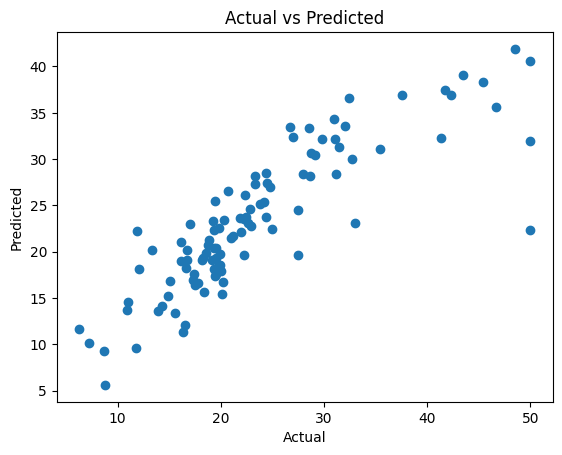

In [72]:
#visual evaluation
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [73]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))

NameError: name 'your_notebook' is not defined